# Flipkart Smartphone Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##  Loading Data

In [3]:
df = pd.read_csv('Processed_Flipdata - Processed_Flipdata (1).csv')

print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
df.head()

Shape: (541, 12)

Column names: ['Unnamed: 0', 'Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize']


,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 50.8+ KB


In [5]:
print(df.isnull().sum())

Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64


##  Data Cleaning & adding new columns

In [17]:
# clean up the price column - it has commas like "7,299" so remove those first
df['Price'] = df['Prize'].str.replace(',', '').astype(float)

# brand is just the first word of the model name
df['Brand'] = df['Model'].str.split().str[0]

# put each phone into a price bucket based on its price
def price_segment(price):
    if price < 7000:
        return 'Budget (<7K)'
    elif price < 15000:
        return 'Lower Mid (7-15K)'
    elif price < 25000:
        return 'Mid (15-25K)'
    elif price < 50000:
        return 'Upper Mid (25-50K)'
    else:
        return 'Premium (50K+)'

df['Price_Segment'] = df['Price'].apply(price_segment)

df[['Model', 'Brand', 'Price', 'Price_Segment']].head()

,Model,Brand,Price,Price_Segment
0,Infinix SMART 7,Infinix,7299.0,Lower Mid (7-15K)
1,Infinix SMART 7,Infinix,7299.0,Lower Mid (7-15K)
2,MOTOROLA G32,MOTOROLA,11999.0,Lower Mid (7-15K)
3,POCO C50,POCO,5649.0,Budget (<7K)
4,Infinix HOT 30i,Infinix,8999.0,Lower Mid (7-15K)


In [7]:
df.describe().round(2)

,Unnamed: 0,Memory,RAM,Battery_,AI Lens,Mobile Height,Price
count,541.00,541.00,541.00,541.00,541.00,541.00,541.00
mean,289.71,110.55,5.40,4871.59,0.06,16.43,16228.38
std,182.36,60.60,1.98,780.15,0.24,2.52,10793.59
min,0.00,16.00,2.00,800.00,0.00,4.50,920.00
25%,135.00,64.00,4.00,5000.00,0.00,16.51,9290.00
50%,273.00,128.00,6.00,5000.00,0.00,16.71,13499.00
75%,434.00,128.00,8.00,5000.00,0.00,16.94,19280.00
max,642.00,256.00,8.00,7000.00,1.00,41.94,80999.00


##  Brand 

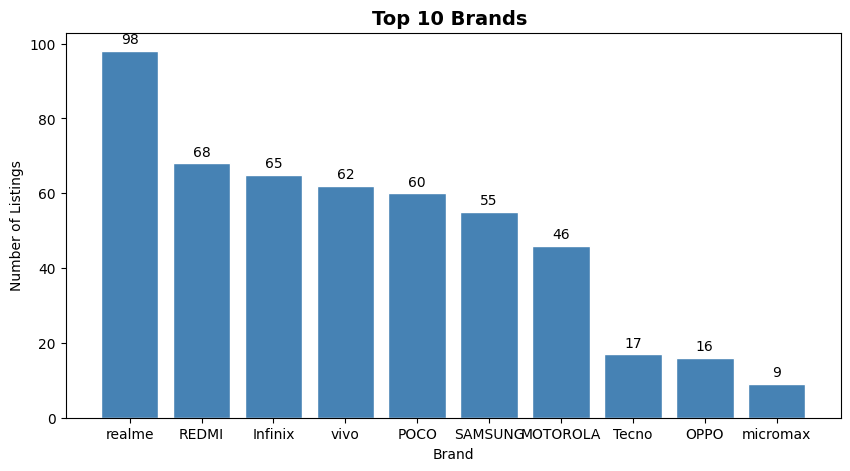

In [8]:
brand_counts = df['Brand'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(brand_counts.index, brand_counts.values, color='steelblue', edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title('Top 10 Brands ', fontsize=14, fontweight='bold')
ax.set_xlabel('Brand')
ax.set_ylabel('Number of Listings')

plt.show()

C:\Users\RAJ BAJAJ\AppData\Local\Temp\ipykernel_8608\3454812386.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'₹{v/1000:.0f}K' for v in ax.get_xticks()])


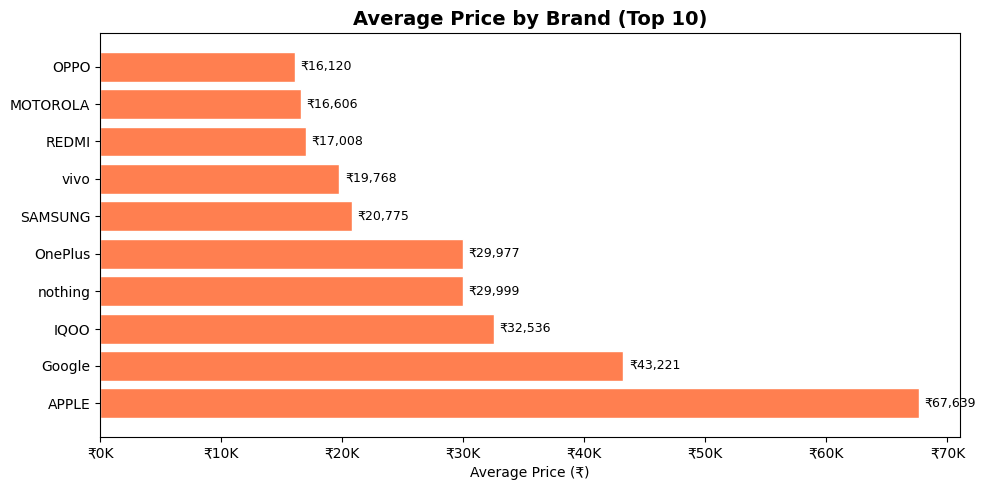

In [9]:
brand_avg_price = df.groupby('Brand')['Price'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(brand_avg_price.index, brand_avg_price.values, color='coral', edgecolor='white')
ax.bar_label(bars, labels=[f'₹{v:,.0f}' for v in brand_avg_price.values], padding=4, fontsize=9)
ax.set_title('Average Price by Brand (Top 10)', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Price (₹)')
ax.set_xticklabels([f'₹{v/1000:.0f}K' for v in ax.get_xticks()])
plt.tight_layout()
plt.show()

##  Price Distribution & Segmentation

C:\Users\RAJ BAJAJ\AppData\Local\Temp\ipykernel_8608\476358886.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([f'₹{v/1000:.0f}K' for v in axes[0].get_xticks()])


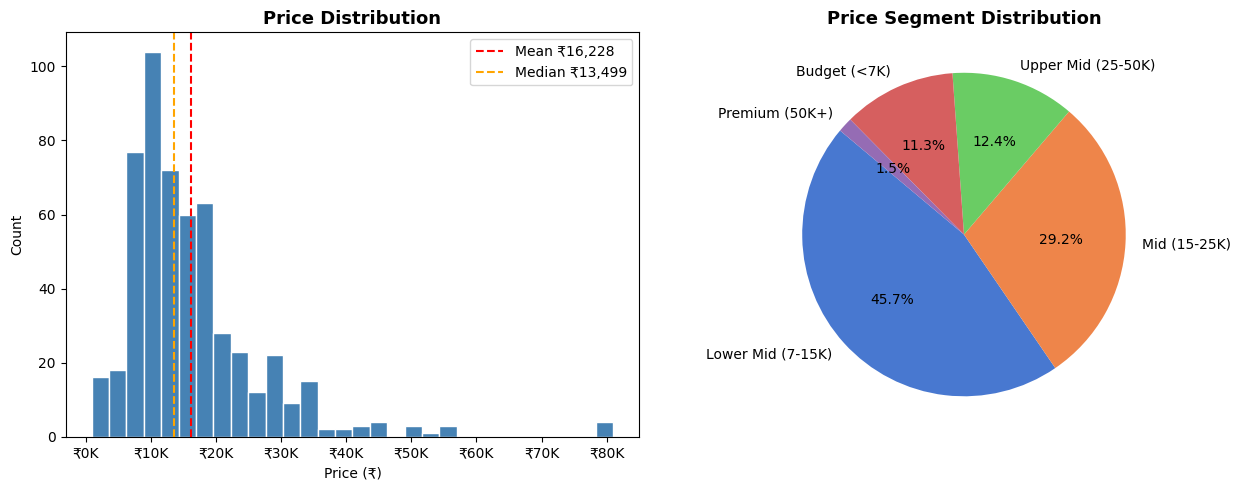

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['Price'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df['Price'].mean(), color='red', linestyle='--', label=f"Mean ₹{df['Price'].mean():,.0f}")
axes[0].axvline(df['Price'].median(), color='orange', linestyle='--', label=f"Median ₹{df['Price'].median():,.0f}")
axes[0].set_title('Price Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_xticklabels([f'₹{v/1000:.0f}K' for v in axes[0].get_xticks()])

seg_counts = df['Price_Segment'].value_counts()
axes[1].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('muted', len(seg_counts)))
axes[1].set_title('Price Segment Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

##  RAM & Storage 

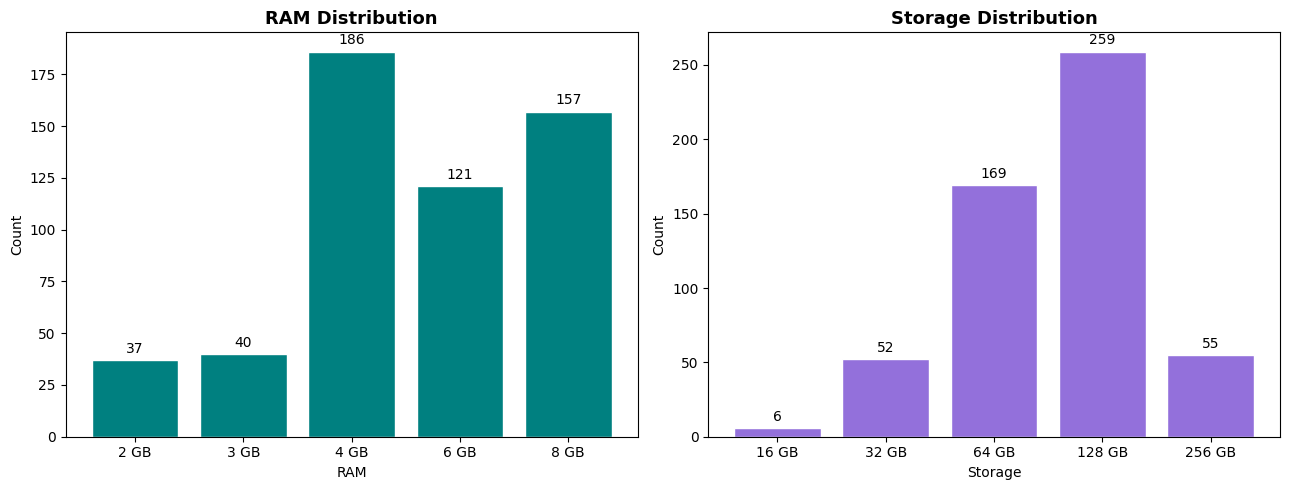

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ram_counts = df['RAM'].value_counts().sort_index()
bars1 = axes[0].bar([f'{r} GB' for r in ram_counts.index], ram_counts.values, color='teal', edgecolor='white')
axes[0].bar_label(bars1, padding=3)
axes[0].set_title('RAM Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('RAM')
axes[0].set_ylabel('Count')

mem_counts = df['Memory'].value_counts().sort_index()
bars2 = axes[1].bar([f'{m} GB' for m in mem_counts.index], mem_counts.values, color='mediumpurple', edgecolor='white')
axes[1].bar_label(bars2, padding=3)
axes[1].set_title('Storage Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Storage')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

C:\Users\RAJ BAJAJ\AppData\Local\Temp\ipykernel_8608\767541328.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'₹{v/1000:.0f}K' for v in ax.get_yticks()])


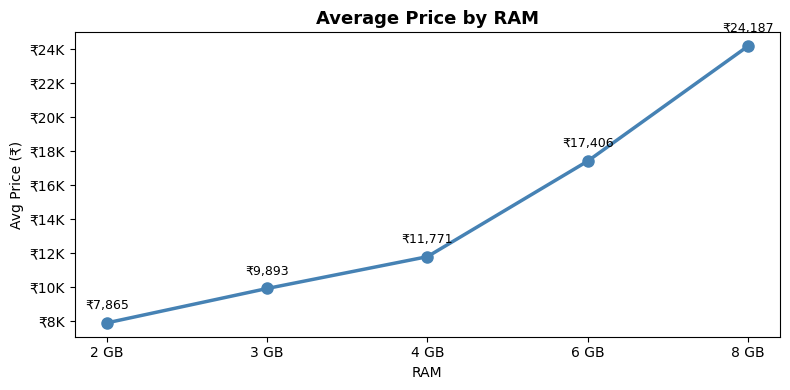

RAM
2     7864.702703
3     9893.400000
4    11770.924731
6    17405.966942
8    24186.668790
Name: Price, dtype: float64

In [12]:
ram_price = df.groupby('RAM')['Price'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([f'{r} GB' for r in ram_price.index], ram_price.values, marker='o', linewidth=2.5,
        color='steelblue', markersize=8)
for i, (x, y) in enumerate(zip(ram_price.index, ram_price.values)):
    ax.annotate(f'₹{y:,.0f}', (f'{x} GB', y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax.set_title('Average Price by RAM', fontsize=13, fontweight='bold')
ax.set_xlabel('RAM')
ax.set_ylabel('Avg Price (₹)')
ax.set_yticklabels([f'₹{v/1000:.0f}K' for v in ax.get_yticks()])
plt.tight_layout()
plt.show()
ram_price

##  Battery 

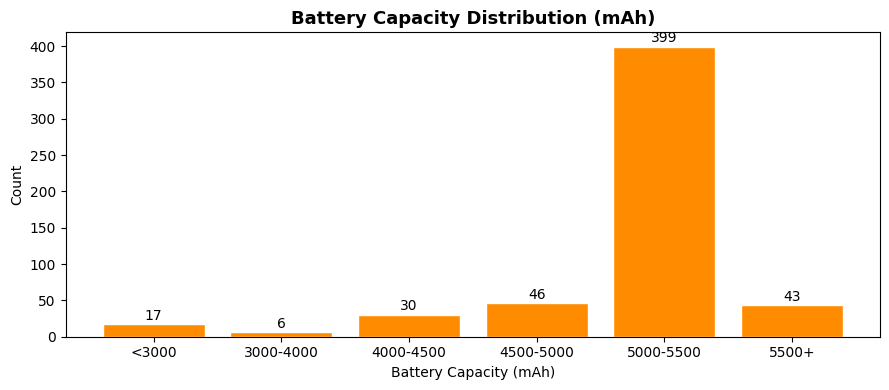


5000 mAh phones: 389 (71.9% of catalog)


In [13]:

def battery_group(mah):
    if mah < 3000:
        return  '<3000'
    elif mah  < 4000:
        return  '3000-4000'
    elif mah < 4500:
        return '4000-4500'
    elif mah < 5000:
        return '4500-5000'
    elif mah < 5500:
        return '5000-5500'
    else:
        return '5500+'

df['Battery_Group'] = df['Battery_'].apply(battery_group)

group_order = ['<3000', '3000-4000', '4000-4500', '4500-5000', '5000-5500', '5500+']
bat_counts = df['Battery_Group'].value_counts().reindex(group_order)

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(bat_counts.index, bat_counts.values, color='darkorange', edgecolor='white')

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        int(bar.get_height()),
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('Battery Capacity Distribution (mAh)', fontsize=13, fontweight='bold')
ax.set_xlabel('Battery Capacity (mAh)')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

# 5000 mAh dominates — let's see by how much
count_5000 = (df['Battery_'] == 5000).sum()
pct_5000 = (df['Battery_'] == 5000).mean() * 100
print(f"\n5000 mAh phones: {count_5000} ({pct_5000:.1f}% of catalog)")

##  Correlation 

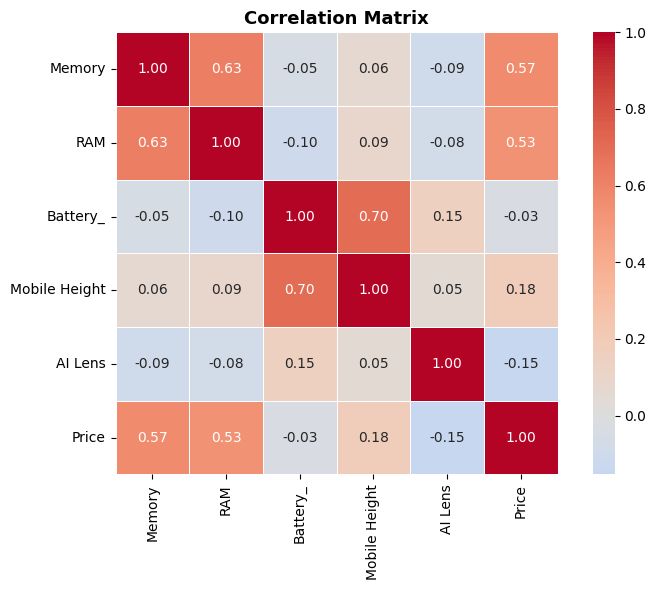

In [14]:
corr_cols = ['Memory', 'RAM', 'Battery_', 'Mobile Height', 'AI Lens', 'Price']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##  Price vs RAM & Storage 

C:\Users\RAJ BAJAJ\AppData\Local\Temp\ipykernel_8608\2622211979.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels([f'₹{v/1000:.0f}K' for v in axes[0].get_yticks()])
C:\Users\RAJ BAJAJ\AppData\Local\Temp\ipykernel_8608\2622211979.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels([f'₹{v/1000:.0f}K' for v in axes[1].get_yticks()])


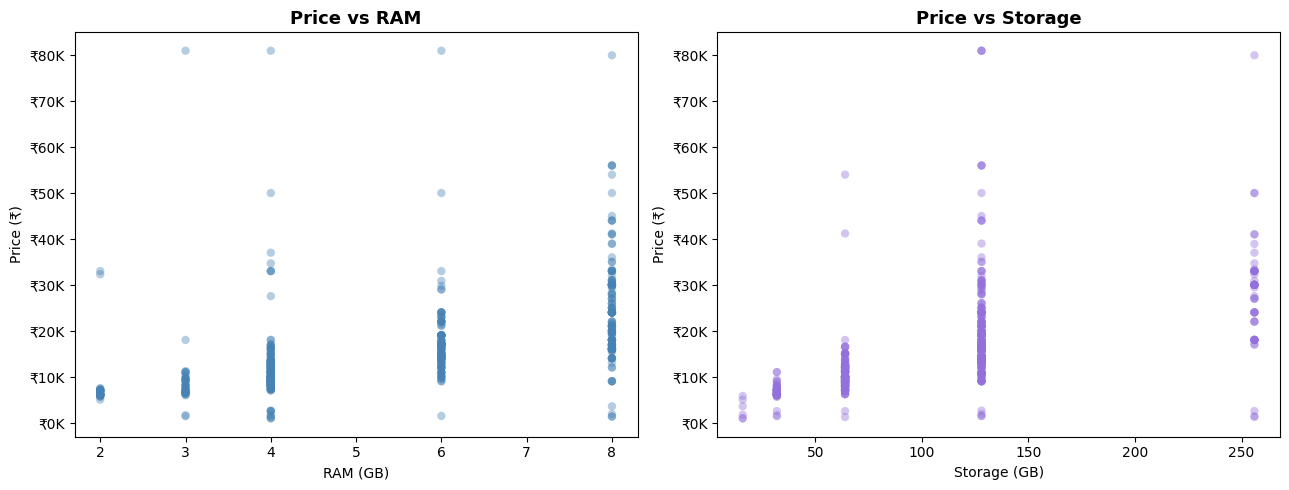

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['RAM'], df['Price'], alpha=0.4, color='steelblue', edgecolors='none')
axes[0].set_title('Price vs RAM', fontsize=13, fontweight='bold')
axes[0].set_xlabel('RAM (GB)')
axes[0].set_ylabel('Price (₹)')
axes[0].set_yticklabels([f'₹{v/1000:.0f}K' for v in axes[0].get_yticks()])

axes[1].scatter(df['Memory'], df['Price'], alpha=0.4, color='mediumpurple', edgecolors='none')
axes[1].set_title('Price vs Storage', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Storage (GB)')
axes[1].set_ylabel('Price (₹)')
axes[1].set_yticklabels([f'₹{v/1000:.0f}K' for v in axes[1].get_yticks()])

plt.tight_layout()
plt.show()

##  AI Lens 

C:\Users\RAJ BAJAJ\AppData\Local\Temp\ipykernel_8608\1862903352.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels([f'₹{v/1000:.0f}K' for v in axes[1].get_yticks()])


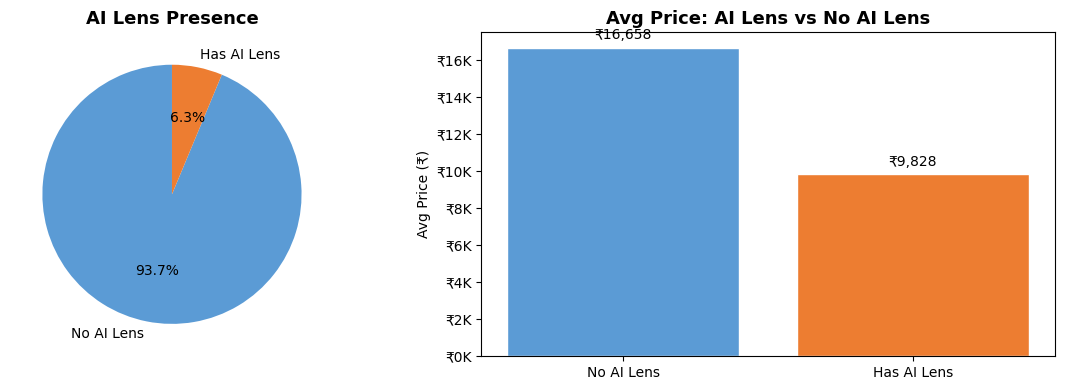

In [16]:
ai_counts = df['AI Lens'].value_counts()
ai_labels = {0: 'No AI Lens', 1: 'Has AI Lens'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(ai_counts, labels=[ai_labels[i] for i in ai_counts.index],
            autopct='%1.1f%%', colors=['#5B9BD5', '#ED7D31'], startangle=90)
axes[0].set_title('AI Lens Presence', fontsize=13, fontweight='bold')

ai_price = df.groupby('AI Lens')['Price'].mean()
bars = axes[1].bar([ai_labels[i] for i in ai_price.index], ai_price.values,
                   color=['#5B9BD5', '#ED7D31'], edgecolor='white')
axes[1].bar_label(bars, labels=[f'₹{v:,.0f}' for v in ai_price.values], padding=4)
axes[1].set_title('Avg Price: AI Lens vs No AI Lens', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Price (₹)')
axes[1].set_yticklabels([f'₹{v/1000:.0f}K' for v in axes[1].get_yticks()])

plt.tight_layout()
plt.show()

---